# PaluScope — Phase 0 — 01 Exploration des données
**Responsable :** Membre 1 · **Bloc A** (compréhension et inspection des données)

**Dataset :** Microscopy Malaria Dataset, split `plasmodium-phonecamera` (Makerere AI Lab, CC0 1.0)
Frottis épais, Field stain, ×1000, photos smartphone. Annotations : boîtes englobantes de plasmodiums.

**Objectifs de ce notebook**
1. Inventorier les fichiers (images et annotations) et vérifier leur correspondance
2. Vérifier dimensions, formats, canaux
3. Lire les annotations et produire des statistiques
4. Visualiser des exemples avec leurs boîtes
5. Noter les anomalies

In [1]:
from pathlib import Path
import re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
RAW_DIR = Path("../../data/raw")   # à adapter si besoin
assert RAW_DIR.exists(), f"Dossier introuvable : {RAW_DIR.resolve()}"
RAW_DIR.resolve()

WindowsPath('C:/Users/hp/Desktop/PaluScope/PaluScope/data/raw')

## 1. Inventaire des fichiers

In [3]:
images = sorted(p for p in RAW_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
annots = sorted(p for p in RAW_DIR.rglob("*") if p.suffix.lower() in {".html", ".xml"})
print("Images      :", len(images))
print("Annotations :", len(annots))
print("Extensions  :", pd.Series([p.suffix.lower() for p in RAW_DIR.rglob('*') if p.is_file()]).value_counts().to_dict())

img_stems = {p.stem for p in images}
ann_stems = {p.stem for p in annots}
print("Images sans annotation :", len(img_stems - ann_stems))
print("Annotations sans image :", len(ann_stems - img_stems))
print("Exemples d'images sans annotation :", sorted(img_stems - ann_stems)[:5])

Images      : 1182
Annotations : 1182
Extensions  : {'.jpg': 1182, '.xml': 1182, '': 1}
Images sans annotation : 0
Annotations sans image : 0
Exemples d'images sans annotation : []


## 2. Dimensions, canaux, formats

In [4]:
rows = []
for p in images:
    with Image.open(p) as im:
        rows.append({"name": p.name, "stem": p.stem, "width": im.width, "height": im.height,
                     "mode": im.mode, "format": im.format, "size_kb": p.stat().st_size / 1024})
df_img = pd.DataFrame(rows)
display(df_img.describe(include="all").T)
print(df_img.groupby(["width", "height", "mode"]).size())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,1182,1182,plasmodium-phone-1182.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stem,1182,1182,plasmodium-phone-1182,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
width,1182.0,NaN,NaN,NaN,750.0,0.0,750.0,750.0,750.0,750.0,750.0
height,1182.0,NaN,NaN,NaN,750.0,0.0,750.0,750.0,750.0,750.0,750.0
mode,1182,1,RGB,1182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
format,1182,1,JPEG,1182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size_kb,1182.0,NaN,NaN,NaN,101.609362,7.779409,83.8125,95.635742,102.526367,107.592773,124.969727


width  height  mode
750    750     RGB     1182
dtype: int64


## 3. Lecture des annotations
Les fichiers `.xml` contiennent a priori des boîtes de type Pascal VOC. Le parseur ci-dessous est **tolérant** (regex)
car un `.html` n'est pas toujours du XML valide. **À vérifier sur un fichier réel** avant de continuer.

In [5]:
# Aperçu brut d'un fichier d'annotation : à lire attentivement
sample_ann = annots[0]
print(sample_ann)
print(sample_ann.read_text(errors="ignore")[:1500])

..\..\data\raw\plasmodium-phonecamera\plasmodium-phone-0001.xml
<annotation>
	<source>
		<database>Makerere Automated Lab Diagnostics Database</database>
		<annotation>Makerere University</annotation>
		<image>Mulago National Referral Hospital</image>
	</source>
	<segmented>0</segmented>
	<object>
		<label>plasmodium</label>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<occluded>0</occluded>
		<bndbox>
			<xmin>290.3885</xmin>
			<ymin>370.8361</ymin>
			<xmax>331.6554</xmax>
			<ymax>410.8361</ymax>
		</bndbox>
	</object>
	<object>
		<label>plasmodium</label>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<occluded>0</occluded>
		<bndbox>
			<xmin>265.0507</xmin>
			<ymin>413.9105</ymin>
			<xmax>305.0507</xmax>
			<ymax>453.9105</ymax>
		</bndbox>
	</object>
	<object>
		<label>plasmodium</label>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<occluded>0</occluded>
		<bndbox>
			<xmin>111.7568</xmin>
			<ymin>264.4172</ymin>
			<xmax>151.7568</xmax>
			<ym

In [12]:
def parse_boxes(path):
    """Retourne la liste des boîtes d'un fichier d'annotation.
    Cherche les balises <label>, <xmin>, <ymin>, <xmax>, <ymax> (format type Pascal VOC).
    """
    txt = Path(path).read_text(errors="ignore")
    boxes = []
    for obj in re.findall(r"<object>(.*?)</object>", txt, flags=re.S | re.I):
        def g(tag):
            m = re.search(rf"<{tag}>\s*([^<\s]+)\s*</{tag}>", obj, flags=re.I)
            return m.group(1) if m else None
        try:
            boxes.append({"label": g("label"),
                          "xmin": float(g("xmin")), "ymin": float(g("ymin")),
                          "xmax": float(g("xmax")), "ymax": float(g("ymax"))})
        except (TypeError, ValueError):
            pass   # boîte illisible : à compter comme anomalie
    return boxes

print(parse_boxes(sample_ann)[:3])

[{'label': 'plasmodium', 'xmin': 290.3885, 'ymin': 370.8361, 'xmax': 331.6554, 'ymax': 410.8361}, {'label': 'plasmodium', 'xmin': 265.0507, 'ymin': 413.9105, 'xmax': 305.0507, 'ymax': 453.9105}, {'label': 'plasmodium', 'xmin': 111.7568, 'ymin': 264.4172, 'xmax': 151.7568, 'ymax': 304.4172}]


In [13]:
recs = []
for p in annots:
    for b in parse_boxes(p):
        recs.append({"stem": p.stem, **b})
df_box = pd.DataFrame(recs)
if len(df_box):
    df_box["w"] = df_box.xmax - df_box.xmin
    df_box["h"] = df_box.ymax - df_box.ymin
    df_box["area"] = df_box.w * df_box.h
print("Boîtes lues :", len(df_box))
display(df_box.describe().T if len(df_box) else "Aucune boîte lue : adapter parse_boxes au format réel")
if len(df_box):
    print(df_box.label.value_counts())

Boîtes lues : 7628


,count,mean,std,min,25%,50%,75%,max
xmin,7628.0,350.096334,208.416837,-19.256000,172.5676,346.1318,526.030400,730.000000
ymin,7628.0,365.466414,207.508990,-20.000000,192.2044,370.8361,545.667200,730.000000
xmax,7628.0,390.038613,208.352030,21.000000,212.5676,386.1318,565.547775,770.000000
ymax,7628.0,405.355768,207.523014,21.000000,232.2044,410.8361,585.667200,770.000000
w,7628.0,39.942279,2.550689,1.266900,40.0000,40.0000,40.000000,71.428600
h,7628.0,39.889353,2.408377,1.266800,40.0000,40.0000,40.000000,62.500000
area,7628.0,1598.919048,126.917794,1.604909,1600.0000,1600.0000,1600.000000,3826.530102


label
plasmodium    7628
Name: count, dtype: int64


## 4. Statistiques par image

Images sans aucun parasite annoté : 234


count    1182.000000
mean        6.453469
std         5.417610
min         0.000000
25%         2.000000
50%         6.000000
75%        10.000000
max        27.000000
Name: n_parasites, dtype: float64

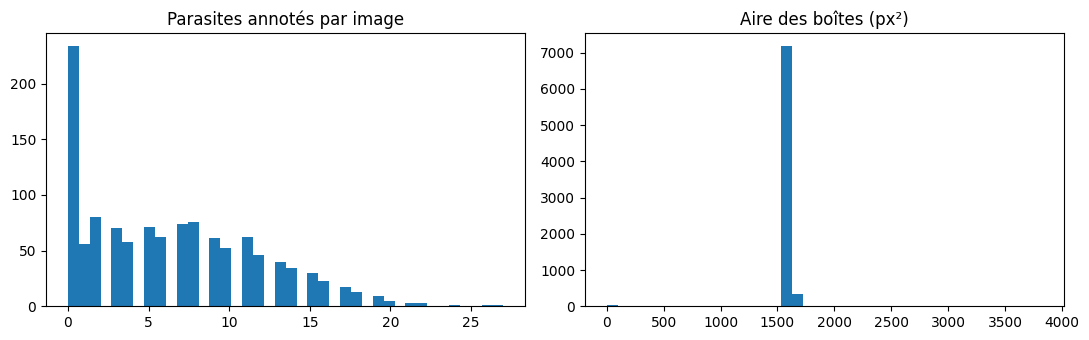

In [14]:
if len(df_box):
    per_img = df_box.groupby("stem").size().rename("n_parasites")
    df = df_img.merge(per_img, on="stem", how="left").fillna({"n_parasites": 0})
    print("Images sans aucun parasite annoté :", int((df.n_parasites == 0).sum()))
    display(df.n_parasites.describe())

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].hist(df.n_parasites, bins=40); ax[0].set_title("Parasites annotés par image")
    ax[1].hist(df_box.area, bins=40);    ax[1].set_title("Aire des boîtes (px²)")
    plt.tight_layout(); plt.show()

## 5. Visualisation d'exemples avec leurs boîtes

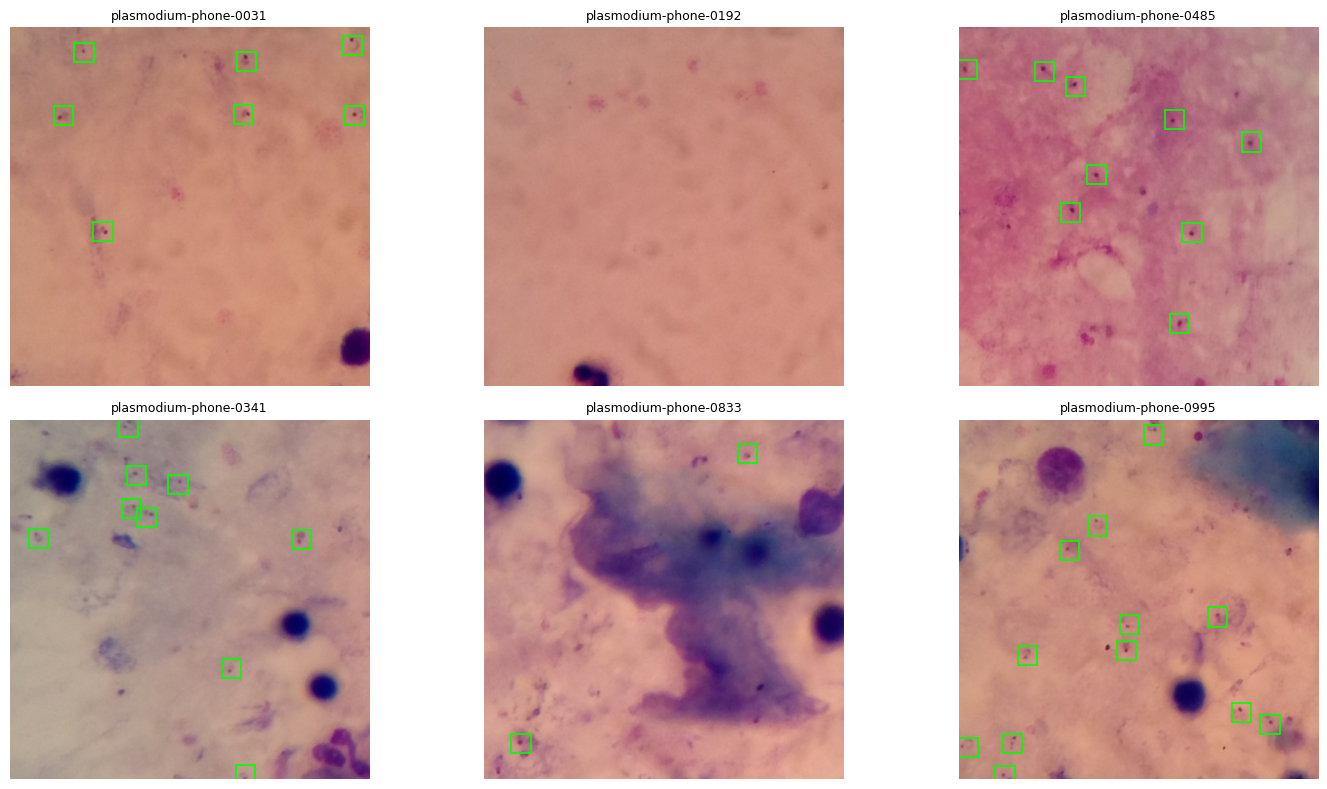

In [15]:
def show(stem_list, ncols=3):
    n = len(stem_list); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    for ax, stem in zip(np.ravel(axes), stem_list):
        p = next(q for q in images if q.stem == stem)
        ax.imshow(Image.open(p).convert("RGB"))
        if len(df_box):
            for _, r in df_box[df_box.stem == stem].iterrows():
                ax.add_patch(plt.Rectangle((r.xmin, r.ymin), r.w, r.h, fill=False, edgecolor="lime", lw=1.2))
        ax.set_title(stem, fontsize=9); ax.axis("off")
    for ax in np.ravel(axes)[n:]: ax.axis("off")
    plt.tight_layout(); plt.show()

show(random.sample(sorted(img_stems), 6))

## 6. Aperçu de la qualité (préparation de S0-3 / Quality Analyzer)
Sur un échantillon : luminosité moyenne, contraste (écart-type des niveaux de gris) et netteté (variance du Laplacien).
Ces mesures sont de simples **indicateurs exploratoires** ; le choix final est la responsabilité du Membre 2.

,count,mean,std,min,25%,50%,75%,max
mean,200.0,147.347222,7.213098,125.738046,142.536533,147.893619,152.584709,165.234965
std,200.0,15.686734,7.017286,4.170405,9.505506,15.771188,20.969425,38.465937
lap_var,200.0,9.919484,1.705461,7.015394,8.743662,9.676755,10.914377,16.749027


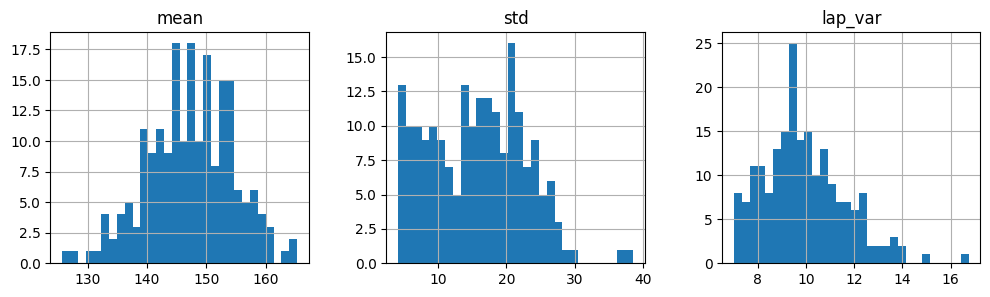

Les plus flous : ['plasmodium-phone-1065', 'plasmodium-phone-0151', 'plasmodium-phone-0366']
Les plus sombres : ['plasmodium-phone-0757', 'plasmodium-phone-0832', 'plasmodium-phone-0733']
Les plus clairs : ['plasmodium-phone-0409', 'plasmodium-phone-0679', 'plasmodium-phone-0121']


In [16]:
import cv2
def quick_stats(p):
    g = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    return {"stem": p.stem, "mean": g.mean(), "std": g.std(), "lap_var": cv2.Laplacian(g, cv2.CV_64F).var()}

sub = random.sample(images, min(200, len(images)))
df_q = pd.DataFrame([quick_stats(p) for p in sub])
display(df_q.describe().T)
df_q.hist(column=["mean", "std", "lap_var"], bins=30, figsize=(12, 3), layout=(1, 3)); plt.show()

print("Les plus flous :", df_q.nsmallest(3, "lap_var").stem.tolist())
print("Les plus sombres :", df_q.nsmallest(3, "mean").stem.tolist())
print("Les plus clairs :", df_q.nlargest(3, "mean").stem.tolist())

In [17]:
W = H = 750
hors = df_box[(df_box.xmin < 0) | (df_box.ymin < 0) | (df_box.xmax > W) | (df_box.ymax > H)]
print(len(hors), "boîtes dépassent l'image, sur", hors.stem.nunique(), "images")
print((df_box.w < 30).sum(), "boîtes de largeur < 30 px;", (df_box.h < 30).sum(), "de hauteur < 30 px")

408 boîtes dépassent l'image, sur 306 images
39 boîtes de largeur < 30 px; 43 de hauteur < 30 px


## 7. Observations et anomalies
## 7. Observations et anomalies

- **Nombre d'images / annotations :** 1182 images (.jpg) et 1182 annotations (.xml). 7628 boîtes de plasmodium lues.
- **Écarts image ↔ annotation :** aucun. Chaque image a son annotation et inversement. 948 images contiennent au moins un parasite, 234 n'en contiennent aucun.
- **Dimensions et formats observés :** toutes les images font 750 × 750 px, RGB, JPEG, entre 84 et 125 Ko.
- **Format des annotations :** XML de type Pascal VOC, avec `<label>` (une seule classe : plasmodium) et `<bndbox>` (xmin, ymin, xmax, ymax). Le parseur lit les balises par regex.
- **Anomalies :**
  - Boîtes de taille quasi fixe (40 × 40 px en médiane et aux quartiles) : elles ne donnent pas la taille réelle des parasites.
  - Boîtes qui dépassent l'image (xmin jusqu'à −19, xmax jusqu'à 770 pour une image de 750 px), certaines tronquées (largeur minimale 1,27 px). À clipper. Nombre concerné : *à compléter*.
  - Écart entre les 7245 parasites annoncés par la description du dataset et les 7628 comptés.
  - Un fichier sans extension à identifier.
  - Aucune étiquette de qualité (flou, exposition) dans le dataset.
- **Variabilité visible (netteté, éclairage, couleurs) :**
  - Couleurs très variables : tons roses ou beiges pour certaines images, violets ou bleutés pour d'autres.
  - Éclairage assez homogène (luminosité moyenne de 147, entre 126 et 165 sur l'échantillon).
  - Contraste variable : écart-type de 4 à 38, avec des images très pâles (ex. plasmodium-phone-0502).
  - Netteté : la variance du Laplacien est faible et resserrée (7 à 17). Elle sépare mal nets et flous, d'autres mesures sont à tester.
  - Parasites très petits, visibles comme de petites taches sombres.

## 8. À étudier plus tard
- Origine de l'écart 7245 / 7628 parasites
- Contenu du fichier sans extension
- Normalisation de la couleur entre images (Phase 1)
